# Movie Recommendation System Pipeline

This notebook provides a reproducible, end-to-end pipeline for training, evaluating,
and interactively demoing a sequence-based movie recommender (SequenceRecommender).

Notebook overview:
- Data loading and preprocessing (MovieLens).\n
- Architecture comparison (RNN / LSTM / GRU).\n
- Optimizer and learning-rate tuning.\n
- Interactive recommendation demo (ipywidgets).\n
\n
Execution notes: the notebook defaults to CPU execution for broad compatibility.\n
If you have CUDA and want to use it, set `USE_CUDA = True` in the runtime configuration cell.

In [34]:
# Environment and runtime configuration
import os
import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from src.dataset import load_data, process_data, collate_fn, MovieSequenceDataset
from src.model import SequenceRecommender
from src.train import train_with_oom_fallback
from src.metrics import evaluate_model
from torch.utils.data import DataLoader

plt.style.use('ggplot')

# Runtime knobs (CPU-first)
USE_CUDA = False  # set True only when you intentionally want GPU execution
SEED = 42

def set_seed(seed=SEED):
    """Set deterministic seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
    except Exception:
        pass
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

set_seed(SEED)
device = 'cuda' if (USE_CUDA and torch.cuda.is_available()) else 'cpu'
print('Using device:', device)

Using device: cpu


## 1. Load Data

This section loads the MovieLens dataset, applies chronological splits, and performs the
minimal preprocessing required for sequence recommendation (mapping movie and user IDs,
reserving a padding token, and truncating/padding histories).

Adjust `DATA_DIR` and `MAX_SEQ_LEN` in the next code cell if you need different inputs.

In [35]:
# Load and preprocess the MovieLens data (chronological splits)
DATA_DIR = 'data'
MAX_SEQ_LEN = 50  # truncate/pad user histories to this length

try:
    ratings_df, movies_df = load_data(DATA_DIR)
except Exception as e:
    raise RuntimeError(f'Failed to load data from {DATA_DIR}: {e}')

train_data, val_data, test_data, movie2idx, user2idx = process_data(ratings_df, max_seq_len=MAX_SEQ_LEN)

print(f'Num train pairs: {len(train_data)}')
print(f'Num val pairs: {len(val_data)}')
print(f'Num test pairs: {len(test_data)}')

train_dataset = MovieSequenceDataset(train_data)
val_dataset = MovieSequenceDataset(val_data)
test_dataset = MovieSequenceDataset(test_data)

num_users = len(user2idx)
num_movies = len(movie2idx) + 1  # reserve 0 for padding

EVAL_BATCH_SIZE = 256
test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Num train pairs: 791718
Num val pairs: 93652
Num test pairs: 96719


In [36]:
# Cache behavior: use existing cache unless FORCE_RETRAIN is set
CACHE_DIR = os.path.join('artifacts', 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_FILE = os.path.join(CACHE_DIR, 'training_cache.pt')
FORCE_RETRAIN = False
SKIP_TRAINING = os.path.exists(CACHE_FILE) and not FORCE_RETRAIN
results_arch = {}
results_opt = {}
best_model = None
best_arch = None
if SKIP_TRAINING:
    print('Found existing training cache; loading summary results for replay.')
    import src.model as _legacy_model_module
    import sys
    sys.modules.setdefault('model', _legacy_model_module)
    try:
        cache = torch.load(CACHE_FILE, map_location=device, weights_only=False)
    except Exception as e:
        print(f'Warning: failed to load cache ({e}); will retrain.')
        cache = {}
    results_arch = cache.get('results_arch', {})
    results_opt = cache.get('results_opt', {})

    def _replay_epochs(name, train_losses, val_losses):
        total = max(len(train_losses), len(val_losses))
        for e in range(total):
            tr = train_losses[e] if e < len(train_losses) else float('nan')
            va = val_losses[e] if e < len(val_losses) else float('nan')
            print(f'[{name}] Epoch {e+1}/{total} - Train Loss: {tr}  Val Loss: {va}')

    print('\nReplaying saved training epochs from cache...')
    for arch, res in results_arch.items():
        _replay_epochs(f'ARCH-{arch.upper()}', res.get('train_losses', []), res.get('val_losses', []))
    for exp, res in results_opt.items():
        _replay_epochs(f'OPT-{exp}', res.get('train_losses', []), res.get('val_losses', []))

    if results_opt:
        best_exp_name = max(results_opt, key=lambda name: results_opt[name].get('hr10', 0.0))
        best_model = results_opt[best_exp_name].get('model')
        print(f'Loaded best cached optimizer experiment: {best_exp_name}')
    elif results_arch:
        best_arch = max(results_arch, key=lambda name: results_arch[name].get('hr10', 0.0))
        best_model = results_arch[best_arch].get('model')
        print(f'Loaded best cached architecture: {best_arch}')

Found existing training cache; loading summary results for replay.

Replaying saved training epochs from cache...
[ARCH-RNN] Epoch 1/10 - Train Loss: 6.883502073901547  Val Loss: 6.756377806429003
[ARCH-RNN] Epoch 2/10 - Train Loss: 6.220754733488007  Val Loss: 6.538394604875742
[ARCH-RNN] Epoch 3/10 - Train Loss: 6.054562470922954  Val Loss: 6.5411259437519345
[ARCH-RNN] Epoch 4/10 - Train Loss: 5.9695151591432  Val Loss: 6.414721499375307
[ARCH-RNN] Epoch 5/10 - Train Loss: 5.907106273736223  Val Loss: 6.384454865273231
[ARCH-RNN] Epoch 6/10 - Train Loss: 5.8632139217649275  Val Loss: 6.375805706274314
[ARCH-RNN] Epoch 7/10 - Train Loss: 5.841629889957195  Val Loss: 6.3639422987328205
[ARCH-RNN] Epoch 8/10 - Train Loss: 5.813817212930822  Val Loss: 6.349671350802229
[ARCH-RNN] Epoch 9/10 - Train Loss: 5.7811911725088345  Val Loss: 6.353526770742865
[ARCH-RNN] Epoch 10/10 - Train Loss: 5.770899574231685  Val Loss: 6.339730334412205
[ARCH-LSTM] Epoch 1/10 - Train Loss: 6.73437794149789

## 2. Architecture Comparison (RNN / LSTM / GRU)

Compare recurrent backbone choices while keeping other hyperparameters fixed. Each architecture
is trained for a small number of epochs to provide a performance signal (Top-1 accuracy and HR@10).
Use these results to select a backbone for optimizer tuning in the next section.

In [37]:
# Train candidate recurrent architectures (RNN, LSTM, GRU) unless a cache is present
ARCHITECTURES = ['rnn', 'lstm', 'gru']
NUM_EPOCHS_ARCH = 5
START_BATCH_SIZE = 256

if not SKIP_TRAINING:
    results_arch = {}
    for arch in ARCHITECTURES:
        print(f'--- Training {arch.upper()} ---')
        create_model_fn = lambda a=arch: SequenceRecommender(num_users=num_users, num_movies=num_movies, rnn_type=a)
        model, train_losses, val_losses, final_batch_size = train_with_oom_fallback(
            create_model_fn,
            train_dataset,
            val_dataset,
            optimizer_name='adam',
            lr=1e-3,
            num_epochs=NUM_EPOCHS_ARCH,
            device=device,
            start_batch_size=START_BATCH_SIZE,
        )
        top1, hr10 = evaluate_model(model, test_loader, device=device)
        print(f'Test Top-1: {top1:.4f}, HR@10: {hr10:.4f}')
        results_arch[arch] = {
            'model': model,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'top1': top1,
            'hr10': hr10,
        }
else:
    print('Skipping architecture training (cache present).')

Skipping architecture training (cache present).


### Architecture Comparison Results

Summary tables and validation loss curves are shown below. If you already have cached training
results they will be replayed instead of retraining (see the cache control variables in the runtime cell).

,Architecture,Top-1 Acc,HR@10
0,RNN,0.023594,0.129364
1,LSTM,0.020896,0.114972
2,GRU,0.023067,0.117857


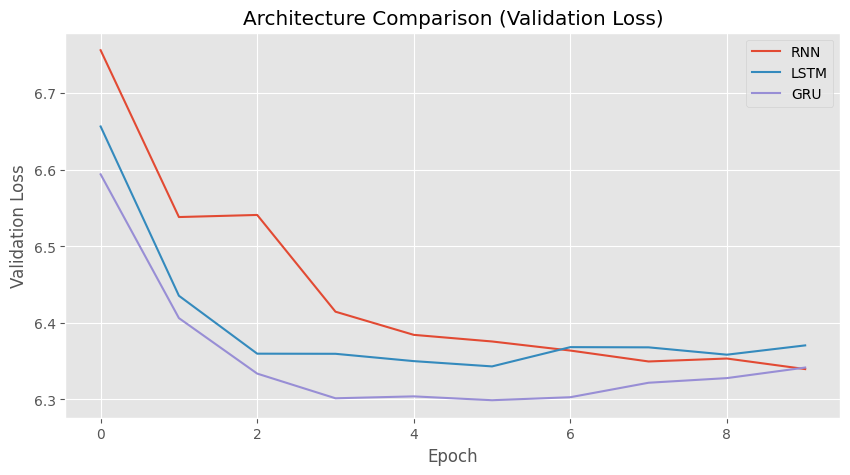

Best architecture: RNN


In [38]:
arch_summary = []
for arch, res in results_arch.items():
    arch_summary.append({'Architecture': arch.upper(), 'Top-1 Acc': res['top1'], 'HR@10': res['hr10']})
df_arch = pd.DataFrame(arch_summary) if arch_summary else pd.DataFrame([])
display(df_arch)

plt.figure(figsize=(10,5))
for arch, res in results_arch.items():
    if res.get('val_losses'):
        plt.plot(res['val_losses'], label=f'{arch.upper()}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Architecture Comparison (Validation Loss)')
plt.legend()
plt.show()

if not df_arch.empty:
    best_arch = df_arch.sort_values(by='HR@10', ascending=False).iloc[0]['Architecture'].lower()
    print(f'Best architecture: {best_arch.upper()}')
else:
    print('No architecture results available yet.')

## 3. Optimizer & Learning Rate Tuning

A small grid search over optimizers and learning rates using the selected backbone. These short
experiments identify promising optimizer configurations; for production training increase
`num_epochs` and tune batch sizes accordingly.

In [39]:
# Grid search over optimizers and learning rates using the chosen backbone
OPTIMIZERS = ['sgd', 'adam']
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
results_opt = {}
if not SKIP_TRAINING:
    if best_arch is None:
        default_backbone = 'lstm'
    else:
        default_backbone = best_arch
    print(f'Running optimizer grid search on backbone: {default_backbone.upper()}')
    for opt in OPTIMIZERS:
        for lr in LEARNING_RATES:
            exp_name = f'{opt.upper()}_lr={lr}'
            print(f'--- Experiment: {exp_name} ---')
            create_model_fn = lambda o=opt: SequenceRecommender(num_users=num_users, num_movies=num_movies, rnn_type=default_backbone)
            model, train_losses, val_losses, _ = train_with_oom_fallback(create_model_fn, train_dataset, val_dataset, optimizer_name=opt, lr=lr, num_epochs=5, device=device, start_batch_size=256)
            top1, hr10 = evaluate_model(model, test_loader, device=device)
            results_opt[exp_name] = {'model': model, 'train_losses': train_losses, 'val_losses': val_losses, 'top1': top1, 'hr10': hr10, 'opt': opt, 'lr': lr}
else:
    print('Skipping optimizer grid search (cache present).')

Skipping optimizer grid search (cache present).


### Optimizer Comparison Results and Save

This cell summarizes optimizer experiments (Top-1 and HR@10) and, if training was executed,
saves a training cache to `artifacts/cache` for faster iteration in subsequent runs. The cache
contains lightweight metrics and model states used by the interactive demo.

""


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30824\2368094536.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


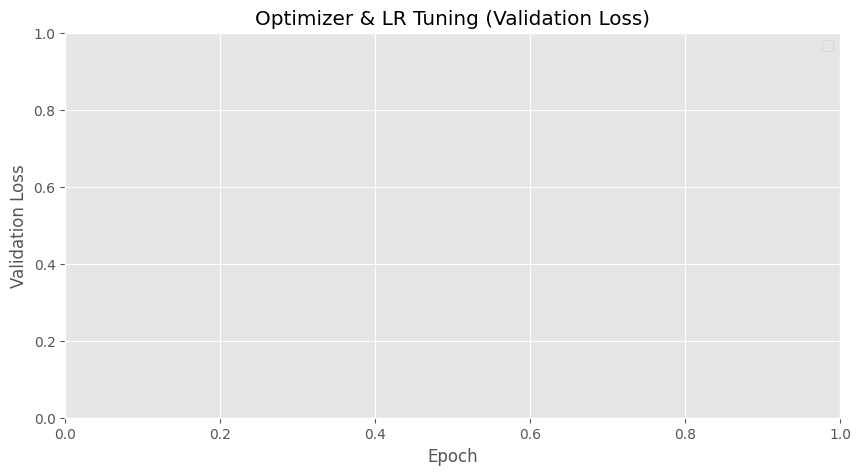

No optimizer results available to select best experiment.


In [40]:
opt_summary = []
for exp_name, res in results_opt.items():
    opt_summary.append({'Experiment': exp_name, 'Optimizer': res['opt'].upper(), 'Learning Rate': res['lr'], 'Top-1 Acc': res['top1'], 'HR@10': res['hr10']})
df_opt = pd.DataFrame(opt_summary) if opt_summary else pd.DataFrame([])
display(df_opt)

plt.figure(figsize=(10,5))
for exp_name, res in results_opt.items():
    if res.get('val_losses'):
        plt.plot(res['val_losses'], label=f"{res['opt'].upper()} lr={res['lr']}")
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Optimizer & LR Tuning (Validation Loss)')
plt.legend()
plt.show()

if not df_opt.empty:
    best_exp_row = df_opt.sort_values(by='HR@10', ascending=False).iloc[0]
    best_exp_name = best_exp_row['Experiment']
    best_model = results_opt[best_exp_name]['model']
    print(f'Winning experiment: {best_exp_name}')
else:
    print('No optimizer results available to select best experiment.')

if not SKIP_TRAINING:
    print('Saving training cache to disk for faster future runs...')
    try:
        torch.save({'results_arch': results_arch, 'results_opt': results_opt}, CACHE_FILE)
    except Exception as e:
        print(f'Warning: failed to save cache ({e})')

## 4. Interactive Recommendation Demo

A lightweight ipywidgets-based UI to build a short viewing history and request the model's
next-item recommendation. This demo uses the `best_model` selected above (either from training
or from the saved cache). If no model is available the demo will instruct how to obtain one.

In [41]:
import re
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

def normalize_title(title):
    if not isinstance(title, str):
        return ''
    t = title.lower().strip()
    t = re.sub(r'\(\d{4}\)', '', t).strip()
    return t

movies_df['normalized_title'] = movies_df['title'].astype(str).apply(normalize_title)
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
mid2title = dict(zip(movies_df['movie_id'], movies_df['title']))

def _find_movie_id_by_title(query):
    q = normalize_title(query)
    if not q:
        return None
    exact = movies_df[movies_df['normalized_title'] == q]
    if not exact.empty:
        return exact.iloc[0]['movie_id']
    contains = movies_df[movies_df['normalized_title'].str.contains(q, na=False)]
    if not contains.empty:
        return contains.iloc[0]['movie_id']
    return None

def predict_next_movie(input_titles, model_to_use):
    model_to_use.eval()
    movie_indices = []
    matched_titles = []
    for t in input_titles:
        mid = _find_movie_id_by_title(t)
        if mid is None:
            print(f'Could not find match for: {t}')
            continue
        if mid not in movie2idx:
            print(f'Movie id {mid} not in training split mapping; skipping')
            continue
        movie_indices.append(movie2idx[mid])
        matched_titles.append(mid2title.get(mid, str(mid)))
    if not movie_indices:
        print('No valid movies found to build a recommendation sequence.')
        return None
    print(f'Mapped input sequence: {matched_titles}')
    seq_tensor = torch.tensor([movie_indices], dtype=torch.long).to(device)
    user_tensor = torch.tensor([0], dtype=torch.long).to(device)
    lengths_tensor = torch.tensor([len(movie_indices)], dtype=torch.long).to(device)
    with torch.no_grad():
        probs = model_to_use.predict(user_tensor, seq_tensor, lengths_tensor)
    probs[0, 0] = -1.0
    pred_idx = int(probs.argmax(dim=-1).item())
    pred_mid = idx2movie.get(pred_idx)
    pred_title = mid2title.get(pred_mid, 'Unknown') if pred_mid is not None else 'Unknown'
    print(f'RECOMMENDED NEXT: {pred_title}')
    return pred_mid

def predict_next_movie_simple(history):
    if 'best_model' in globals() and best_model is not None:
        return predict_next_movie(history, best_model)
    else:
        print('Best model is not available for inference. Ensure training or cache load completed.')
        return None

In [42]:
if 'ui' in globals():
    try:
        ui.close()
    except Exception:
        pass

import ipywidgets as widgets
from IPython.display import display, clear_output

movie_titles = sorted(movies_df['title'].dropna().astype(str).unique().tolist())

search_box = widgets.Text(
    value='',
    placeholder='Search movies by title',
    description='Search',
    layout=widgets.Layout(width='600px'),
)

movies_select = widgets.SelectMultiple(
    options=movie_titles,
    value=(),
    description='Titles',
    layout=widgets.Layout(width='600px', height='220px'),
)

history_output = widgets.Output()
result_output = widgets.Output()
selected_output = widgets.Output()

add_button = widgets.Button(description='Add selected', button_style='info')
predict_button = widgets.Button(description='Predict next', button_style='success')
remove_button = widgets.Button(description='Remove last', button_style='warning')
clear_button = widgets.Button(description='Clear history', button_style='danger')

history_titles = []


def _refresh_movie_options(query=''):
    query = (query or '').strip().lower()
    if query:
        filtered = [title for title in movie_titles if query in title.lower()]
    else:
        filtered = movie_titles
    movies_select.options = filtered


def _render_selected_preview():
    with selected_output:
        clear_output(wait=True)
        selected = list(movies_select.value)
        if selected:
            preview = ', '.join(selected[:5])
            if len(selected) > 5:
                preview += f' ... (+{len(selected) - 5} more)'
            print(f'Selected: {preview}')
        else:
            print('Selected: none')


def _render_history():
    with history_output:
        clear_output(wait=True)
        if history_titles:
            print('Viewing history: ' + ' -> '.join(history_titles))
        else:
            print('Viewing history: empty')


def _predict_from_history():
    with result_output:
        clear_output(wait=True)
        if not history_titles:
            print('Add at least one title before predicting.')
            return
        if best_model is None:
            print('No trained model is available. Load training results or rerun training.')
            return
        predict_next_movie(history_titles, best_model)


def _on_add(_):
    selected = list(movies_select.value)
    if not selected:
        with result_output:
            clear_output(wait=True)
            print('Select one or more movies first.')
        return
    for title in selected:
        if title not in history_titles:
            history_titles.append(title)
    movies_select.value = ()
    _render_history()
    with result_output:
        clear_output(wait=True)
        print(f'Added {len(selected)} title(s) to the history.')


def _on_remove(_):
    with result_output:
        clear_output(wait=True)
        if history_titles:
            removed = history_titles.pop()
            print(f'Removed: {removed}')
            _render_history()
        else:
            print('History is already empty.')


def _on_clear(_):
    history_titles.clear()
    movies_select.value = ()
    search_box.value = ''
    _refresh_movie_options('')
    _render_history()
    with result_output:
        clear_output(wait=True)
        print('History cleared.')


search_box.observe(lambda change: _refresh_movie_options(change['new']), names='value')
movies_select.observe(lambda change: _render_selected_preview(), names='value')
add_button.on_click(_on_add)
remove_button.on_click(_on_remove)
clear_button.on_click(_on_clear)
predict_button.on_click(lambda _: _predict_from_history())

_refresh_movie_options('')
_render_selected_preview()
_render_history()

controls = widgets.HBox([add_button, remove_button, clear_button, predict_button])
ui = widgets.VBox([
    widgets.HTML('<h3>Interactive Movie Recommendation Demo</h3>'),
    widgets.HTML('<p>Search for movies, build a short viewing history, and predict the next title.</p>'),
    search_box,
    movies_select,
    selected_output,
    controls,
    history_output,
    result_output,
])

display(ui)